Task 1 Answers

MNIST is a dataset having images of handwritten digits (0 - 9). Each image in grayscale and has 784 pixels (28 x 28). It has 60,000 training images and 10,000 testing images. Each sample consists of an image and a label. The label is the correct answer that the model must predict.

Normalisation is done for images to make it easier for the model to learn certain shapes and features.

The model will take in an image and will output its prediction for the digit. Our aim is to train this model to make its prediction more and more accurate.

In [42]:
import torch

import torch.nn as nn

from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [ ]:
# For training the model

"""

I found the correct normalisation parameters for MNIST database online. I initially did 0.5 mean and 0.5 sd and that gave me an accuracy of
99.2. So to improve it I changed it to values I found online that work better.

"""

# Btw I prefer type hints, ik it is redundant but it makes me remember what it stores

# Random rotation for training

train_transform: transforms.Compose = transforms.Compose([transforms.RandomRotation(10), transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset: datasets.MNIST = datasets.MNIST(root = "data", train = True, transform = train_transform, download = True)

print("Training data downloaded")


# For testing the model, I didn't add the random rotation as it is not used for testing data

test_transform: transforms.Compose = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

test_dataset: datasets.MNIST = datasets.MNIST(root = "data", train = False, transform = test_transform, download = True)

print("Testing data downloaded")




Training data downloaded
Testing data downloaded


In [32]:
# Training and testing data loaders

train_dataloader: DataLoader = DataLoader(train_dataset, batch_size = 64, shuffle = True)

test_dataloader: DataLoader = DataLoader(test_dataset, batch_size = 64, shuffle = False)

In [33]:
# Verifying a batch by printing the shape of the image and label


image, label = next(iter(train_dataloader))

print(image.shape)

print(label.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


# Ideas Tried

I have tried multiple variants before this one. Instead of putting it in comments and make it clunky, I decided to keep a history of it here.

## Trial 1

The model basically had two conv + Relu layer, two pooling, two linear steps and Relu in between. The shape changed from (1, 28, 28)
-> (64, 26, 26) -> Pooling (64, 13, 13) -> Conv + Relu (64, 11, 11) -> Pooling (64, 5, 5)

Linear (1600) -> Relu -> Linear (128) -> Relu -> Linear (10)

This worked good with lr of 0.001 and gave an accuracy of 99.2.

## Trial 2

I wanted to increase the accuracy a bit more and read about dropout, this disables random neurons during training to prevent the model from
memorising the data. So I added a Dropout layer before Linear to 10. I made first Conv + Relu to 32 channels and second to 64 channels. I also added one more Conv + Relu step. The end shape is (64, 4, 4). The Linear step is from 1024 to 256 to 128 to 10. I kept lr at 0.001.

This gave me an accuracy of 99.36.

## Trial 3

I changed nothing in the model. I used standard normalisation parameters online instead of 0.5.

This gave me an accuracy of 99.38.


## Trial 4

I changed the lr to 0.0007, hoping maybe the learning rate was too fast. But this was too much of a drop and it reduced the accuracy
to 99.32.


## Trial 5

Finally, I set the lr to 0.0009 and kept a dynamic epoch system to train, where the training stops once learning doesn't improve by much for 7 epochs. 

This gave me my maximum accuracy of 99.46.

In [ ]:
# --- The Model ---

"""

We put the (1, 28, 28) image to conv layer with kernel size 3, stride 1 and 32 channels. This gives us (32, 26, 26). Now we apply ReLu and 
 
then go for pooling. We then put it through a conv layer to get (32, 24, 24). We pool with a kernel size 2 and stride 2 to get (32, 12, 12). 

We then apply conv layer with kernel size 3, stride 1 and 64 channels to get (64, 10, 10). We then apply ReLu. We then apply a conv layer to 

get (64, 8, 8). We pool again with kernel size 2 and stride 2 to get (64, 4, 4). Then we flatten to get 1024 features. We then linear to 256, 

then to 128 and then to 10. Between the linear layers we add ReLU to keep the transformation complex. Dropout is to prevent the model 

from memorising the data.


"""

class DigitCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net: nn.Sequential = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size = 3),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size = 3),
            nn.ReLU(),
            nn.MaxPool2d(2, stride = 2),
            nn.Conv2d(32, 64, kernel_size = 3),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size = 3),
            nn.ReLU(),
            nn.MaxPool2d(2, stride = 2),
            nn.Flatten(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(p = 0.2),
            nn.Linear(128, 10)
        )


    def forward(self, x: torch.Tensor) -> torch.Tensor:

        return self.net(x)



In [ ]:
model: DigitCNN = DigitCNN()

criterion: nn.CrossEntropyLoss = nn.CrossEntropyLoss()

"""

I initially tried lr of 0.001. Then I changed it to 0.0007. That was too slow, accuracy went from 99.38 to 99.32. So I incresed it to a

value of 0.0009. This gave me my max of 99.46.


"""

optimizer: torch.optim.Adam = torch.optim.Adam(model.parameters(), lr = 0.0009)

In [ ]:
model.train()

"""

I don't know if there is a better way to do this, but I am training the model untill the loss reduction becomes lower than the best minus

small delta of 1e-3 for 7 epochs consecutively. I keep track of it with these variables. Also, maybe there are better values for lr and

other params which I can find with more trial and error, but this takes 28 mins to run, and I have a human patience limit too ;)


"""

best_loss: float = float("inf")

patience: int = 7

delta: float = 1e-3

epoch: int = 0

while (patience > 0):

    epoch += 1

    losses: list[float] = []

    for images, labels in train_dataloader:

        optimizer.zero_grad()

        outputs: torch.Tensor = model(images)

        loss: torch.Tensor = criterion(outputs, labels)

        losses.append(loss.item())

        loss.backward()

        optimizer.step()

    avg_loss: float = sum(losses) / len(losses)

    if (avg_loss < best_loss - delta):

        best_loss = avg_loss

        patience = 7

    else:

        patience -= 1


    print(f"Epoch {epoch}: Average loss is {sum(losses) / len(losses)}")



Epoch 1: Average loss is 0.1830407436400938
Epoch 2: Average loss is 0.057987586971916465
Epoch 3: Average loss is 0.04257418929882445
Epoch 4: Average loss is 0.035028942447221
Epoch 5: Average loss is 0.03025951151626119
Epoch 6: Average loss is 0.02658914903872804
Epoch 7: Average loss is 0.024568748602777166
Epoch 8: Average loss is 0.020750004691540015
Epoch 9: Average loss is 0.019040945100905426
Epoch 10: Average loss is 0.0164662158268484
Epoch 11: Average loss is 0.017158754438249643
Epoch 12: Average loss is 0.015183806416221324
Epoch 13: Average loss is 0.016309285953281818
Epoch 14: Average loss is 0.013825038578877416
Epoch 15: Average loss is 0.013210606716640216
Epoch 16: Average loss is 0.011071933176096801
Epoch 17: Average loss is 0.013313251203075301
Epoch 18: Average loss is 0.012732949895193134
Epoch 19: Average loss is 0.011106499953820643
Epoch 20: Average loss is 0.010440061233323293
Epoch 21: Average loss is 0.0099551522654466
Epoch 22: Average loss is 0.008735

Total images seen: 10000
Correct results: 9946
Overall accuracy: 0.9946


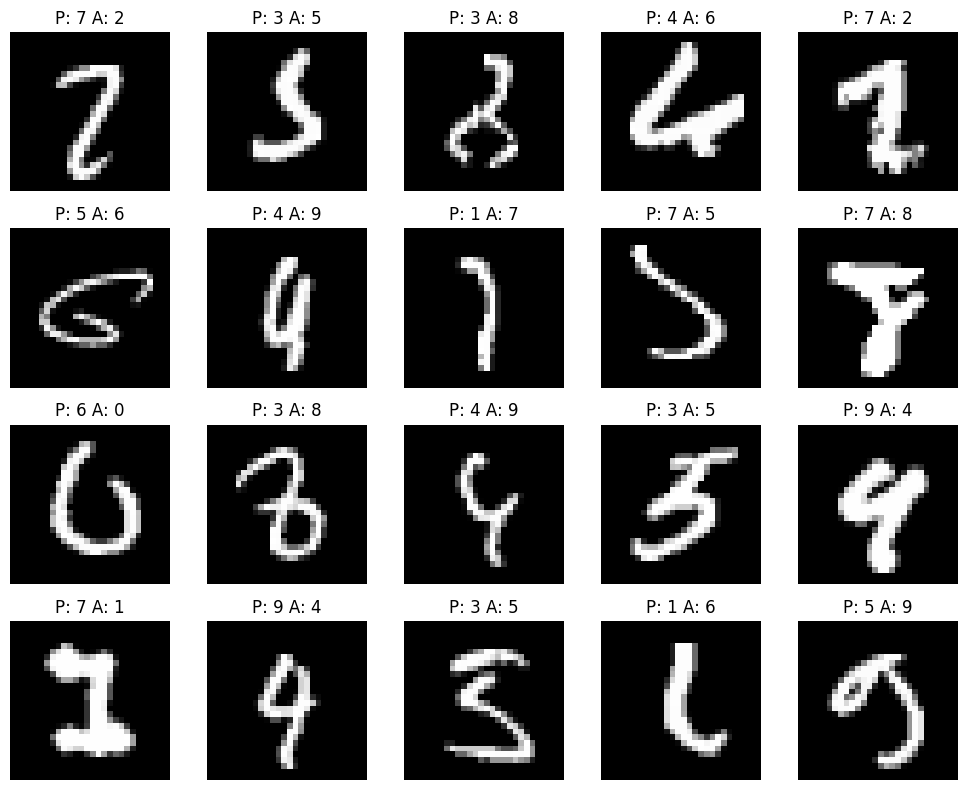

In [ ]:
model.eval()

correct: int = 0

total: int = 0

wrong_images: list[torch.Tensor] = []

wrong_labels: list[int] = []

wrong_predictions: list[int] = []

with torch.no_grad():

    for images, labels in test_dataloader:

        total += labels.shape[0]

        outputs: torch.Tensor = model(images)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == labels).sum().item()
        
        wrong_mask: torch.Tensor = predicted != labels

        for i in range(labels[wrong_mask].shape[0]):

            wrong_labels.append(labels[wrong_mask][i].item())

            wrong_predictions.append(predicted[wrong_mask][i].item())

            wrong_images.append(images[wrong_mask][i].squeeze(0))

# Best accuracy I got is 99.46

print(f"Total images seen: {total}")

print(f"Correct results: {correct}")

print(f"Overall accuracy: {(correct / total):.4f}")

# Showing first 20 mistakes

fig, axes = plt.subplots(4, 5, figsize = (10, 8))

for i, ax in enumerate(axes.flat):

    if (i >= len(wrong_labels)):

        break

    img: torch.Tensor = wrong_images[i]

    img = img * 0.3081 + 0.1307

    ax.imshow(img, cmap = "gray")

    ax.set_title(f"P: {wrong_predictions[i]} A: {wrong_labels[i]}")

    ax.axis("off")

plt.tight_layout()

plt.show()

